# Trabajo Aprendizaje Supervisado Grupo 16

In [1]:
# Importar librerías
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

In [24]:
# Cargar datos desde CSV
data = pd.read_csv('Grupo16.csv', sep=';')


## Procesar valores faltantes - reemplazar con promedios

In [27]:

# Mostrar valores faltantes antes del procesamiento
print("Valores faltantes por columna ANTES del procesamiento:")
print(data.isnull().sum())
print("\nTotal de valores faltantes:", data.isnull().sum().sum())

# Calcular promedios para cada columna numérica
print("\nPromedios calculados:")
promedios = data.mean()
print(promedios)

# Reemplazar valores faltantes con el promedio de cada columna
data_procesado = data.fillna(data.mean())

# Verificar que no hay más valores faltantes
print("\n\nValores faltantes por columna DESPUÉS del procesamiento:")
print(data_procesado.isnull().sum())
print("\nTotal de valores faltantes:", data_procesado.isnull().sum().sum())

# Mostrar primeras filas del dataset procesado
print("\n\nPrimeras filas del dataset procesado:")
print(data_procesado.head(20))

print("\n✓ Datos procesados guardados en la variable 'data_procesado'")

Valores faltantes por columna ANTES del procesamiento:
frecuencia              5
gasto                   5
visitas                 5
devoluciones            5
satisfaccion_cliente    5
valor_cliente           5
cliente_premium         5
dtype: int64

Total de valores faltantes: 35

Promedios calculados:
frecuencia                5.062646
gasto                    62.959758
visitas                  42.448465
devoluciones              2.195192
satisfaccion_cliente      1.472444
valor_cliente           300.957071
cliente_premium            0.29899
dtype: object


Valores faltantes por columna DESPUÉS del procesamiento:
frecuencia              0
gasto                   0
visitas                 0
devoluciones            0
satisfaccion_cliente    0
valor_cliente           0
cliente_premium         0
dtype: int64

Total de valores faltantes: 0


Primeras filas del dataset procesado:
    frecuencia   gasto  visitas  devoluciones  satisfaccion_cliente  \
0     4.300000   83.99    38.43      2.8

In [28]:
data_procesado

,frecuencia,gasto,visitas,devoluciones,satisfaccion_cliente,valor_cliente,cliente_premium
0,4.30,83.99,38.43,2.84,0.61,370.80,True
1,8.42,26.05,47.75,1.30,0.99,237.03,False
2,5.26,139.65,44.99,3.94,1.38,522.98,True
3,6.22,48.49,30.08,1.50,2.41,357.88,False
4,1.19,56.70,62.28,1.35,0.48,75.06,False
...,...,...,...,...,...,...,...
495,4.34,-2.20,24.28,3.16,1.27,161.53,False
496,5.32,48.13,87.92,1.03,2.78,258.45,False
497,4.20,-19.60,17.70,-0.39,0.99,110.69,False
498,3.66,56.41,50.76,2.27,1.34,95.54,False


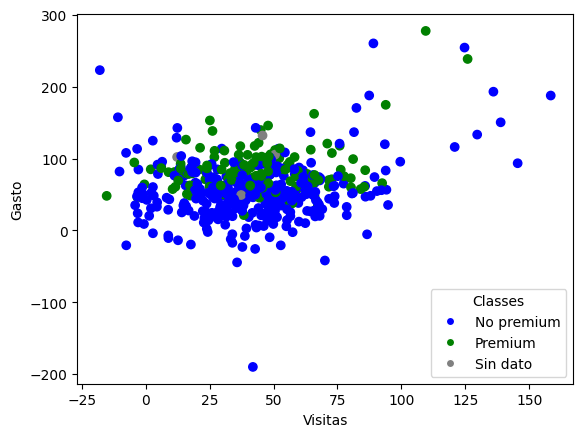

In [23]:
# Mapear clases a colores
color_map = {False: 'blue', True: 'green'}

# Crear la figura y los ejes
fig, ax = plt.subplots()

# Colores para cada punto (rellenar valores no mapeados con gris)
point_colors = data['cliente_premium'].map(color_map).fillna('gray')

# Graficar los puntos
scatter = ax.scatter(
    data['visitas'],
    data['gasto'],
    c=point_colors
)

# Establecer etiquetas de los ejes
ax.set(xlabel='Visitas', ylabel='Gasto')

# Crear leyenda manualmente
legend_elements = [
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='blue', label='No premium'),
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='green', label='Premium'),
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='gray', label='Sin dato')
]
ax.legend(handles=legend_elements, loc="lower right", title="Classes")

plt.show()


## MENCIONAR PRESENCIA DATOS NEGATIVOS "SIN SENTIDO" (ej: VISITAS/MES NEGATIVO)

In [29]:
# Dividir los datos en características (X) y variable objetivo (y)
X = data_procesado.drop('cliente_premium', axis=1)
X = X.drop('valor_cliente', axis=1)
y = data_procesado['cliente_premium']

In [30]:
X

,frecuencia,gasto,visitas,devoluciones,satisfaccion_cliente
0,4.30,83.99,38.43,2.84,0.61
1,8.42,26.05,47.75,1.30,0.99
2,5.26,139.65,44.99,3.94,1.38
3,6.22,48.49,30.08,1.50,2.41
4,1.19,56.70,62.28,1.35,0.48
...,...,...,...,...,...
495,4.34,-2.20,24.28,3.16,1.27
496,5.32,48.13,87.92,1.03,2.78
497,4.20,-19.60,17.70,-0.39,0.99
498,3.66,56.41,50.76,2.27,1.34


In [31]:
y

0       True
1      False
2       True
3      False
4      False
       ...  
495    False
496    False
497    False
498    False
499    False
Name: cliente_premium, Length: 500, dtype: object

In [32]:
# Dividir dataset en conjunto de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [ ]:
# Inicializar y entrenar el modelo de regresión logística
model = LogisticRegression()
y_train = y_train.astype(int)
y_test = y_test.astype(int)

model.fit(X_train, y_train)

ValueError: Unknown label type: unknown. Maybe you are trying to fit a classifier, which expects discrete classes on a regression target with continuous values.

In [ ]:
# Ver los coeficientes y el término de intercepción
print("Coeficientes:", model.coef_)
print("Intercepto:", model.intercept_)

In [ ]:
# Predecir en el conjunto de prueba
y_pred = model.predict(X_test)

In [ ]:
# Calcular precisión
accuracy = accuracy_score(y_test, y_pred)
print("Precisión del modelo de regresión logística en el conjunto de prueba: {:.2f}".format(accuracy))

In [ ]:
# Calcular matriz de confusión
cm = confusion_matrix(y_test, y_pred) # super importante metrica

# Obtener etiquetas únicas presentes en y_test y y_pred
labels = sorted(set(y_test) | set(y_pred))

# Visualizar matriz de confusión
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Matriz de Confusión')
plt.show()

In [ ]:
from sklearn.metrics import classification_report

# Calcular precision, recall y F1-score
report = classification_report(y_test, y_pred, target_names=[str(label) for label in labels])
print("Reporte de Clasificación:")
print(report)

# Diferencia entre precision y recall:
# Precision: considerando mis predicciones de una categoria, cuantas veces tuve la razon en estas predicciones
# Precision visto de arriba hacia abajo en matriz confusion
# en el otro sentido, Recall es ver matriz de izq a derecha
# decimos que se "dejaron pasar" 7 versicolor como virginica
